In [115]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import skew

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

from xgboost import XGBRegressor
import numpy as np

In [63]:
df=pd.read_csv(r"C:\Users\Dell\Downloads\Drployment_unsubervisedML_Assignment_LifeExpectancy_Prediction\Life Expectancy Data.csv")

In [64]:
df.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [65]:
df.shape

(2938, 22)

In [66]:
df.describe

<bound method NDFrame.describe of           Country  Year      Status  Life expectancy   Adult Mortality  \
0     Afghanistan  2015  Developing              65.0            263.0   
1     Afghanistan  2014  Developing              59.9            271.0   
2     Afghanistan  2013  Developing              59.9            268.0   
3     Afghanistan  2012  Developing              59.5            272.0   
4     Afghanistan  2011  Developing              59.2            275.0   
...           ...   ...         ...               ...              ...   
2933     Zimbabwe  2004  Developing              44.3            723.0   
2934     Zimbabwe  2003  Developing              44.5            715.0   
2935     Zimbabwe  2002  Developing              44.8             73.0   
2936     Zimbabwe  2001  Developing              45.3            686.0   
2937     Zimbabwe  2000  Developing              46.0            665.0   

      infant deaths  Alcohol  percentage expenditure  Hepatitis B  Measles   

In [67]:
df.isnull().sum()

Country                              0
Year                                 0
Status                               0
Life expectancy                     10
Adult Mortality                     10
infant deaths                        0
Alcohol                            194
percentage expenditure               0
Hepatitis B                        553
Measles                              0
 BMI                                34
under-five deaths                    0
Polio                               19
Total expenditure                  226
Diphtheria                          19
 HIV/AIDS                            0
GDP                                448
Population                         652
 thinness  1-19 years               34
 thinness 5-9 years                 34
Income composition of resources    167
Schooling                          163
dtype: int64

In [68]:
df.duplicated().sum()

np.int64(0)

In [69]:
df.dtypes

Country                                str
Year                                 int64
Status                                 str
Life expectancy                    float64
Adult Mortality                    float64
infant deaths                        int64
Alcohol                            float64
percentage expenditure             float64
Hepatitis B                        float64
Measles                              int64
 BMI                               float64
under-five deaths                    int64
Polio                              float64
Total expenditure                  float64
Diphtheria                         float64
 HIV/AIDS                          float64
GDP                                float64
Population                         float64
 thinness  1-19 years              float64
 thinness 5-9 years                float64
Income composition of resources    float64
Schooling                          float64
dtype: object

In [70]:
df.drop("Country",axis=1,inplace=True)  #no need of country column

In [71]:
df

,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,19.1,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,18.6,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,18.1,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,17.6,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,17.2,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2933,2004,Developing,44.3,723.0,27,4.36,0.000000,68.0,31,27.1,...,67.0,7.13,65.0,33.6,454.366654,12777511.0,9.4,9.4,0.407,9.2
2934,2003,Developing,44.5,715.0,26,4.06,0.000000,7.0,998,26.7,...,7.0,6.52,68.0,36.7,453.351155,12633897.0,9.8,9.9,0.418,9.5
2935,2002,Developing,44.8,73.0,25,4.43,0.000000,73.0,304,26.3,...,73.0,6.53,71.0,39.8,57.348340,125525.0,1.2,1.3,0.427,10.0
2936,2001,Developing,45.3,686.0,25,1.72,0.000000,76.0,529,25.9,...,76.0,6.16,75.0,42.1,548.587312,12366165.0,1.6,1.7,0.427,9.8


In [72]:
le = LabelEncoder()  #convert status into numerical values for model training
df["Status"] = le.fit_transform(df["Status"])

In [18]:
df

,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,2015,1,65.0,263.0,62,0.01,71.279624,65.0,1154,19.1,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,2014,1,59.9,271.0,64,0.01,73.523582,62.0,492,18.6,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,2013,1,59.9,268.0,66,0.01,73.219243,64.0,430,18.1,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,2012,1,59.5,272.0,69,0.01,78.184215,67.0,2787,17.6,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,2011,1,59.2,275.0,71,0.01,7.097109,68.0,3013,17.2,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2933,2004,1,44.3,723.0,27,4.36,0.000000,68.0,31,27.1,...,67.0,7.13,65.0,33.6,454.366654,12777511.0,9.4,9.4,0.407,9.2
2934,2003,1,44.5,715.0,26,4.06,0.000000,7.0,998,26.7,...,7.0,6.52,68.0,36.7,453.351155,12633897.0,9.8,9.9,0.418,9.5
2935,2002,1,44.8,73.0,25,4.43,0.000000,73.0,304,26.3,...,73.0,6.53,71.0,39.8,57.348340,125525.0,1.2,1.3,0.427,10.0
2936,2001,1,45.3,686.0,25,1.72,0.000000,76.0,529,25.9,...,76.0,6.16,75.0,42.1,548.587312,12366165.0,1.6,1.7,0.427,9.8


In [73]:
df.fillna(df.median(numeric_only=True), inplace=True)

,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,2015,1,65.0,263.0,62,0.01,71.279624,65.0,1154,19.1,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,2014,1,59.9,271.0,64,0.01,73.523582,62.0,492,18.6,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,2013,1,59.9,268.0,66,0.01,73.219243,64.0,430,18.1,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,2012,1,59.5,272.0,69,0.01,78.184215,67.0,2787,17.6,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,2011,1,59.2,275.0,71,0.01,7.097109,68.0,3013,17.2,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2933,2004,1,44.3,723.0,27,4.36,0.000000,68.0,31,27.1,...,67.0,7.13,65.0,33.6,454.366654,12777511.0,9.4,9.4,0.407,9.2
2934,2003,1,44.5,715.0,26,4.06,0.000000,7.0,998,26.7,...,7.0,6.52,68.0,36.7,453.351155,12633897.0,9.8,9.9,0.418,9.5
2935,2002,1,44.8,73.0,25,4.43,0.000000,73.0,304,26.3,...,73.0,6.53,71.0,39.8,57.348340,125525.0,1.2,1.3,0.427,10.0
2936,2001,1,45.3,686.0,25,1.72,0.000000,76.0,529,25.9,...,76.0,6.16,75.0,42.1,548.587312,12366165.0,1.6,1.7,0.427,9.8


In [20]:
df.isnull().sum()

Year                               0
Status                             0
Life expectancy                    0
Adult Mortality                    0
infant deaths                      0
Alcohol                            0
percentage expenditure             0
Hepatitis B                        0
Measles                            0
 BMI                               0
under-five deaths                  0
Polio                              0
Total expenditure                  0
Diphtheria                         0
 HIV/AIDS                          0
GDP                                0
Population                         0
 thinness  1-19 years              0
 thinness 5-9 years                0
Income composition of resources    0
Schooling                          0
dtype: int64

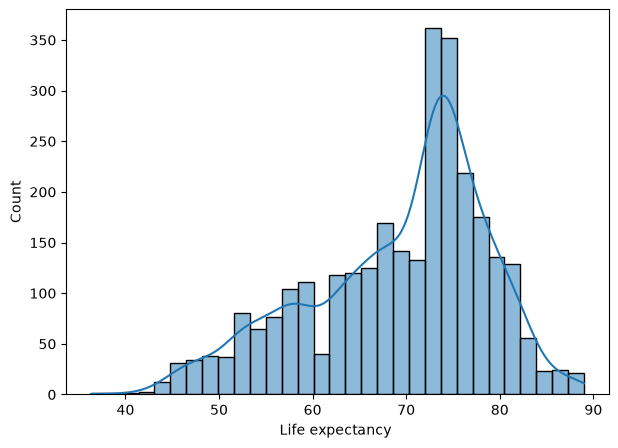

In [74]:
#EDA
#distribution of life expectancy
plt.figure(figsize=(7,5))
sns.histplot(df["Life expectancy "], kde=True)
plt.show()


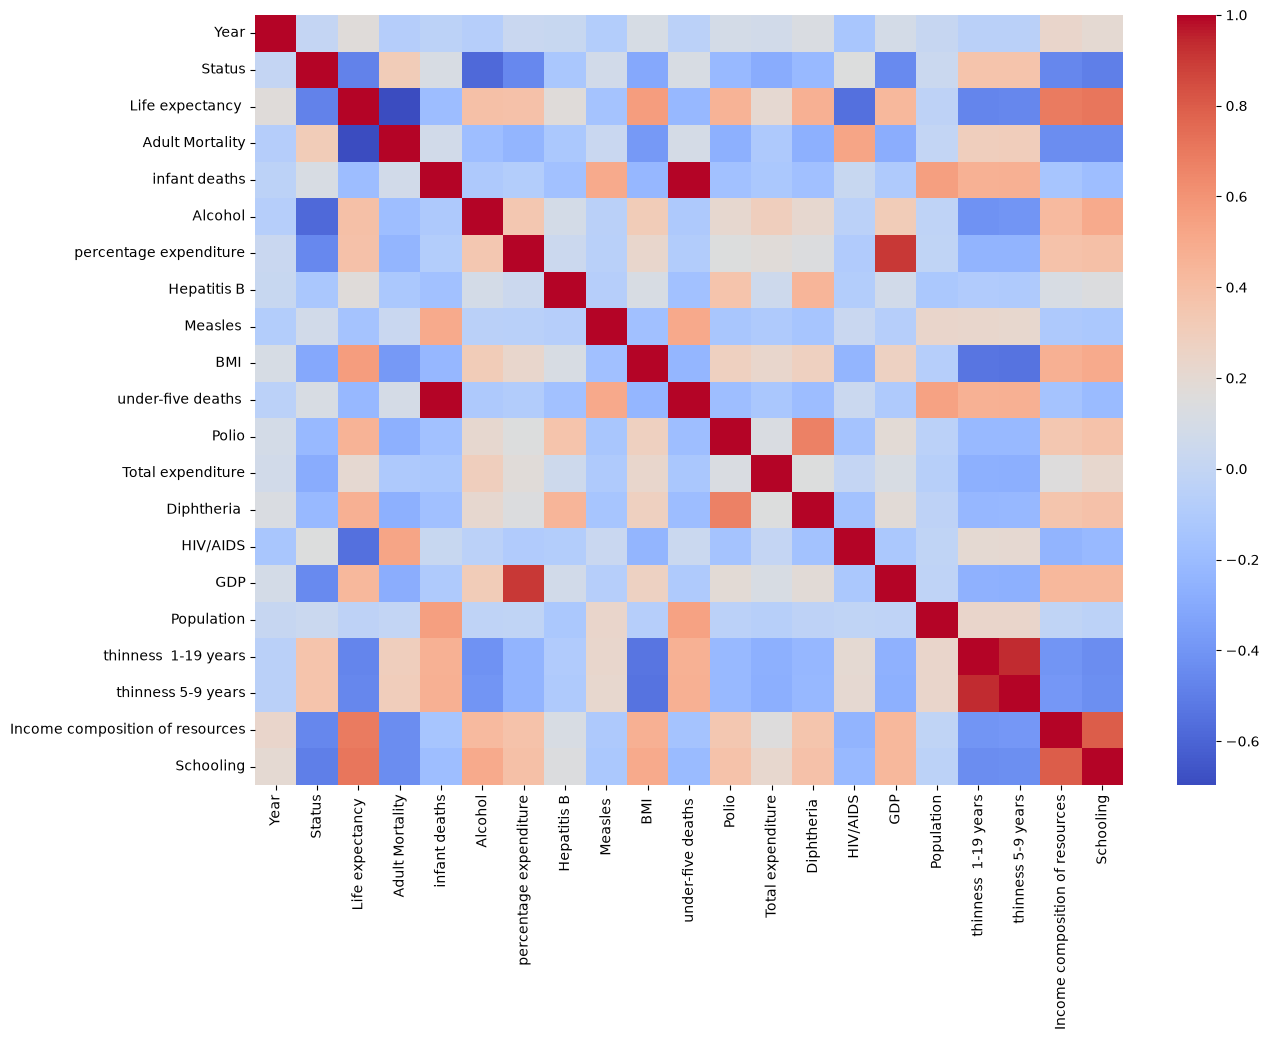

In [75]:
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.show()

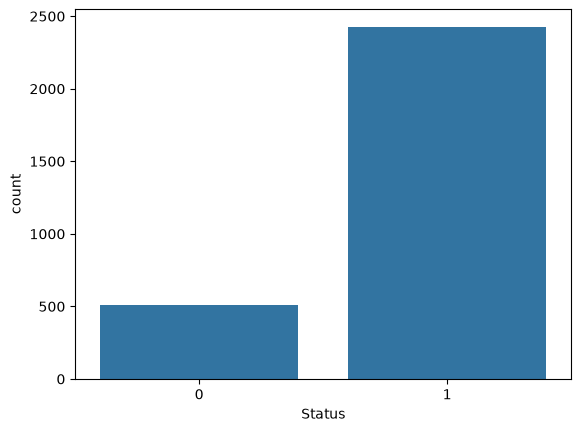

In [76]:
#status count
sns.countplot(x="Status", data=df)
plt.show()

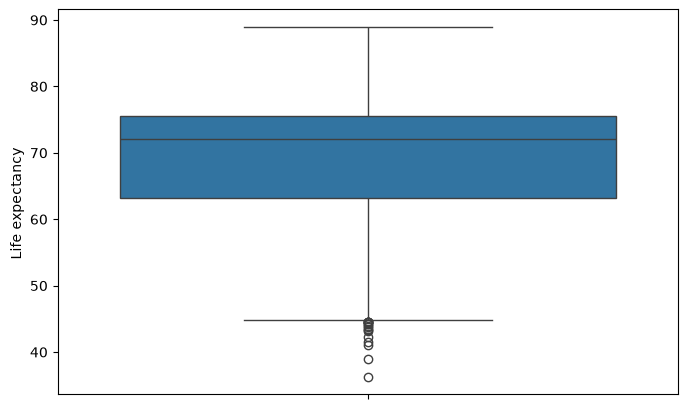

In [77]:
plt.figure(figsize=(8,5))
sns.boxplot(df["Life expectancy "])
plt.show()

In [78]:
df.columns = df.columns.str.strip()
print(df.columns.tolist())

['Year', 'Status', 'Life expectancy', 'Adult Mortality', 'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B', 'Measles', 'BMI', 'under-five deaths', 'Polio', 'Total expenditure', 'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'thinness  1-19 years', 'thinness 5-9 years', 'Income composition of resources', 'Schooling']


In [79]:
df.columns = df.columns.str.replace(r'\s+', ' ', regex=True)

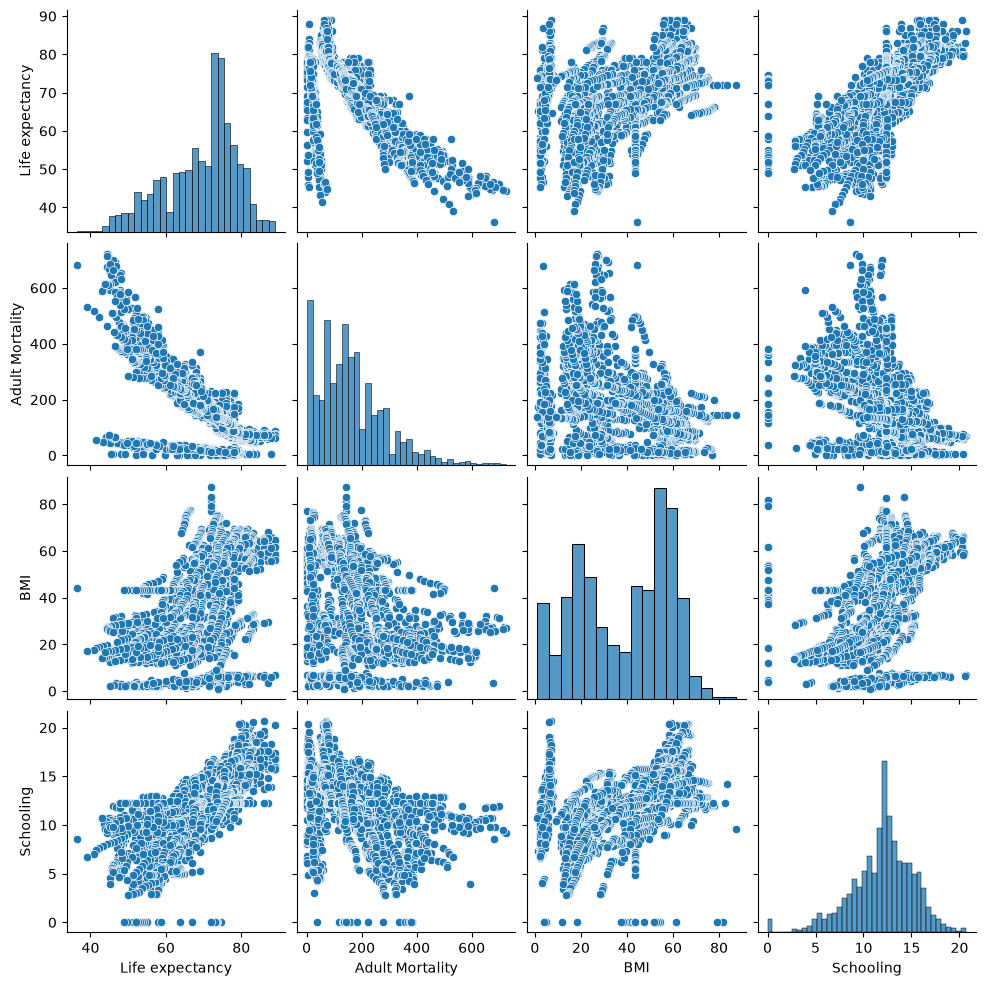

In [80]:
sns.pairplot(df[[
'Life expectancy','Adult Mortality','BMI','Schooling']])

In [81]:
#check skewness
numeric = df.select_dtypes(include=np.number)
skewness = numeric.apply(skew)
print(skewness.sort_values(ascending=False))


Population                         17.963660
infant deaths                       9.781965
under-five deaths                   9.490216
Measles                             9.436511
HIV/AIDS                            5.393357
percentage expenditure              4.649676
GDP                                 3.541946
thinness 5-9 years                  1.794777
thinness 1-19 years                 1.728613
Adult Mortality                     1.177298
Total expenditure                   0.660771
Alcohol                             0.649246
Year                               -0.006406
BMI                                -0.229040
Schooling                          -0.634727
Life expectancy                    -0.642063
Income composition of resources    -1.211907
Status                             -1.717361
Diphtheria                         -2.082502
Polio                              -2.107833
Hepatitis B                        -2.280532
dtype: float64


In [82]:
from sklearn.preprocessing import PowerTransformer

skewed_cols = [
    'Population',
    'infant deaths',
    'under-five deaths',
    'Measles',
    'HIV/AIDS',
    'percentage expenditure',
    'GDP',
    'thinness 5-9 years',
    'thinness 1-19 years',
    'Adult Mortality'
]

pt = PowerTransformer(method='yeo-johnson')

df[skewed_cols] = pt.fit_transform(df[skewed_cols])

In [83]:
numeric = df.select_dtypes(include=np.number)
skewness_after = numeric.skew()
print(skewness_after.sort_values(ascending=False))

HIV/AIDS                           0.969222
Total expenditure                  0.661108
Alcohol                            0.649578
Measles                            0.180945
infant deaths                      0.175445
under-five deaths                  0.167610
Population                         0.036155
thinness 1-19 years                0.019438
thinness 5-9 years                 0.014504
GDP                                0.000636
Year                              -0.006409
percentage expenditure            -0.014370
Adult Mortality                   -0.079300
BMI                               -0.229157
Schooling                         -0.635052
Life expectancy                   -0.642391
Income composition of resources   -1.212526
Status                            -1.718238
Diphtheria                        -2.083566
Polio                             -2.108909
Hepatitis B                       -2.281697
dtype: float64


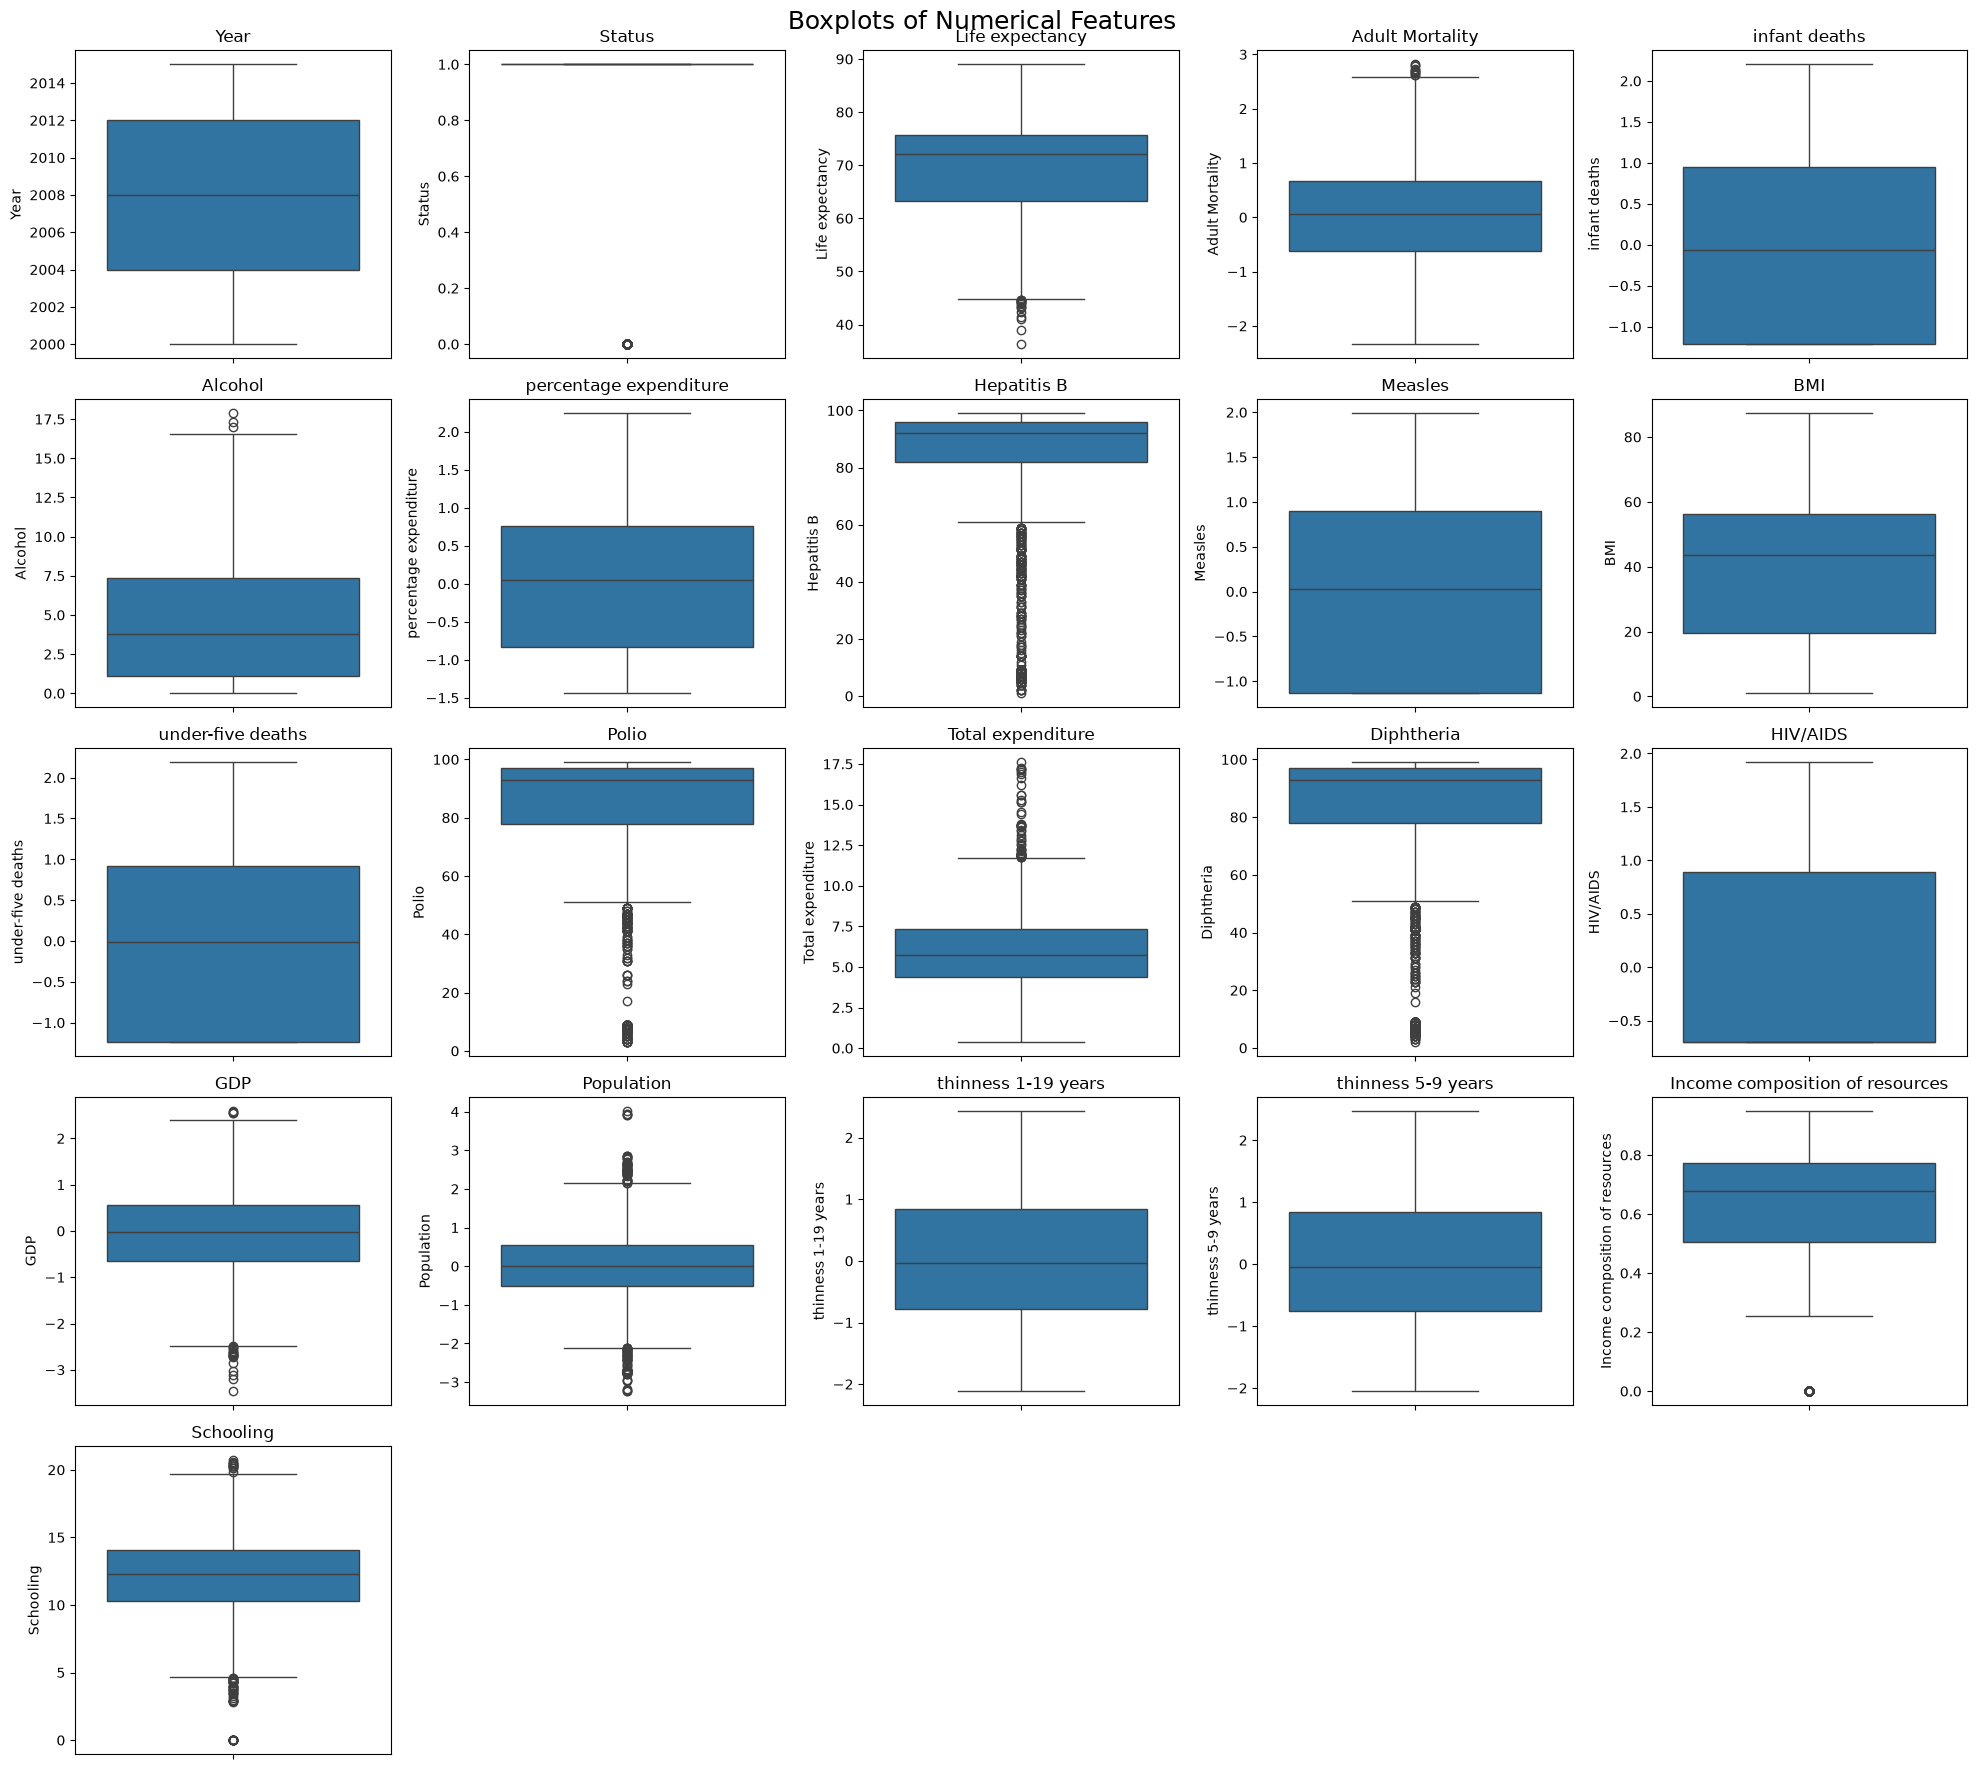

In [86]:
#treaing outliers
numeric_cols = df.select_dtypes(include=np.number).columns

# Create boxplots in one figure
fig, axes = plt.subplots(5, 5, figsize=(20, 18))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)

# Remove unused plots
for i in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[i])

plt.suptitle('Boxplots of Numerical Features', fontsize=18)
plt.tight_layout()
plt.show()

In [87]:
# Columns where outliers need to be treated
outlier_cols = [
    'Adult Mortality',
    'Alcohol',
    'Hepatitis B',
    'Polio',
    'Total expenditure',
    'Diphtheria',
    'GDP',
    'Population',
    'Income composition of resources',
    'Schooling'
]

# IQR capping
for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

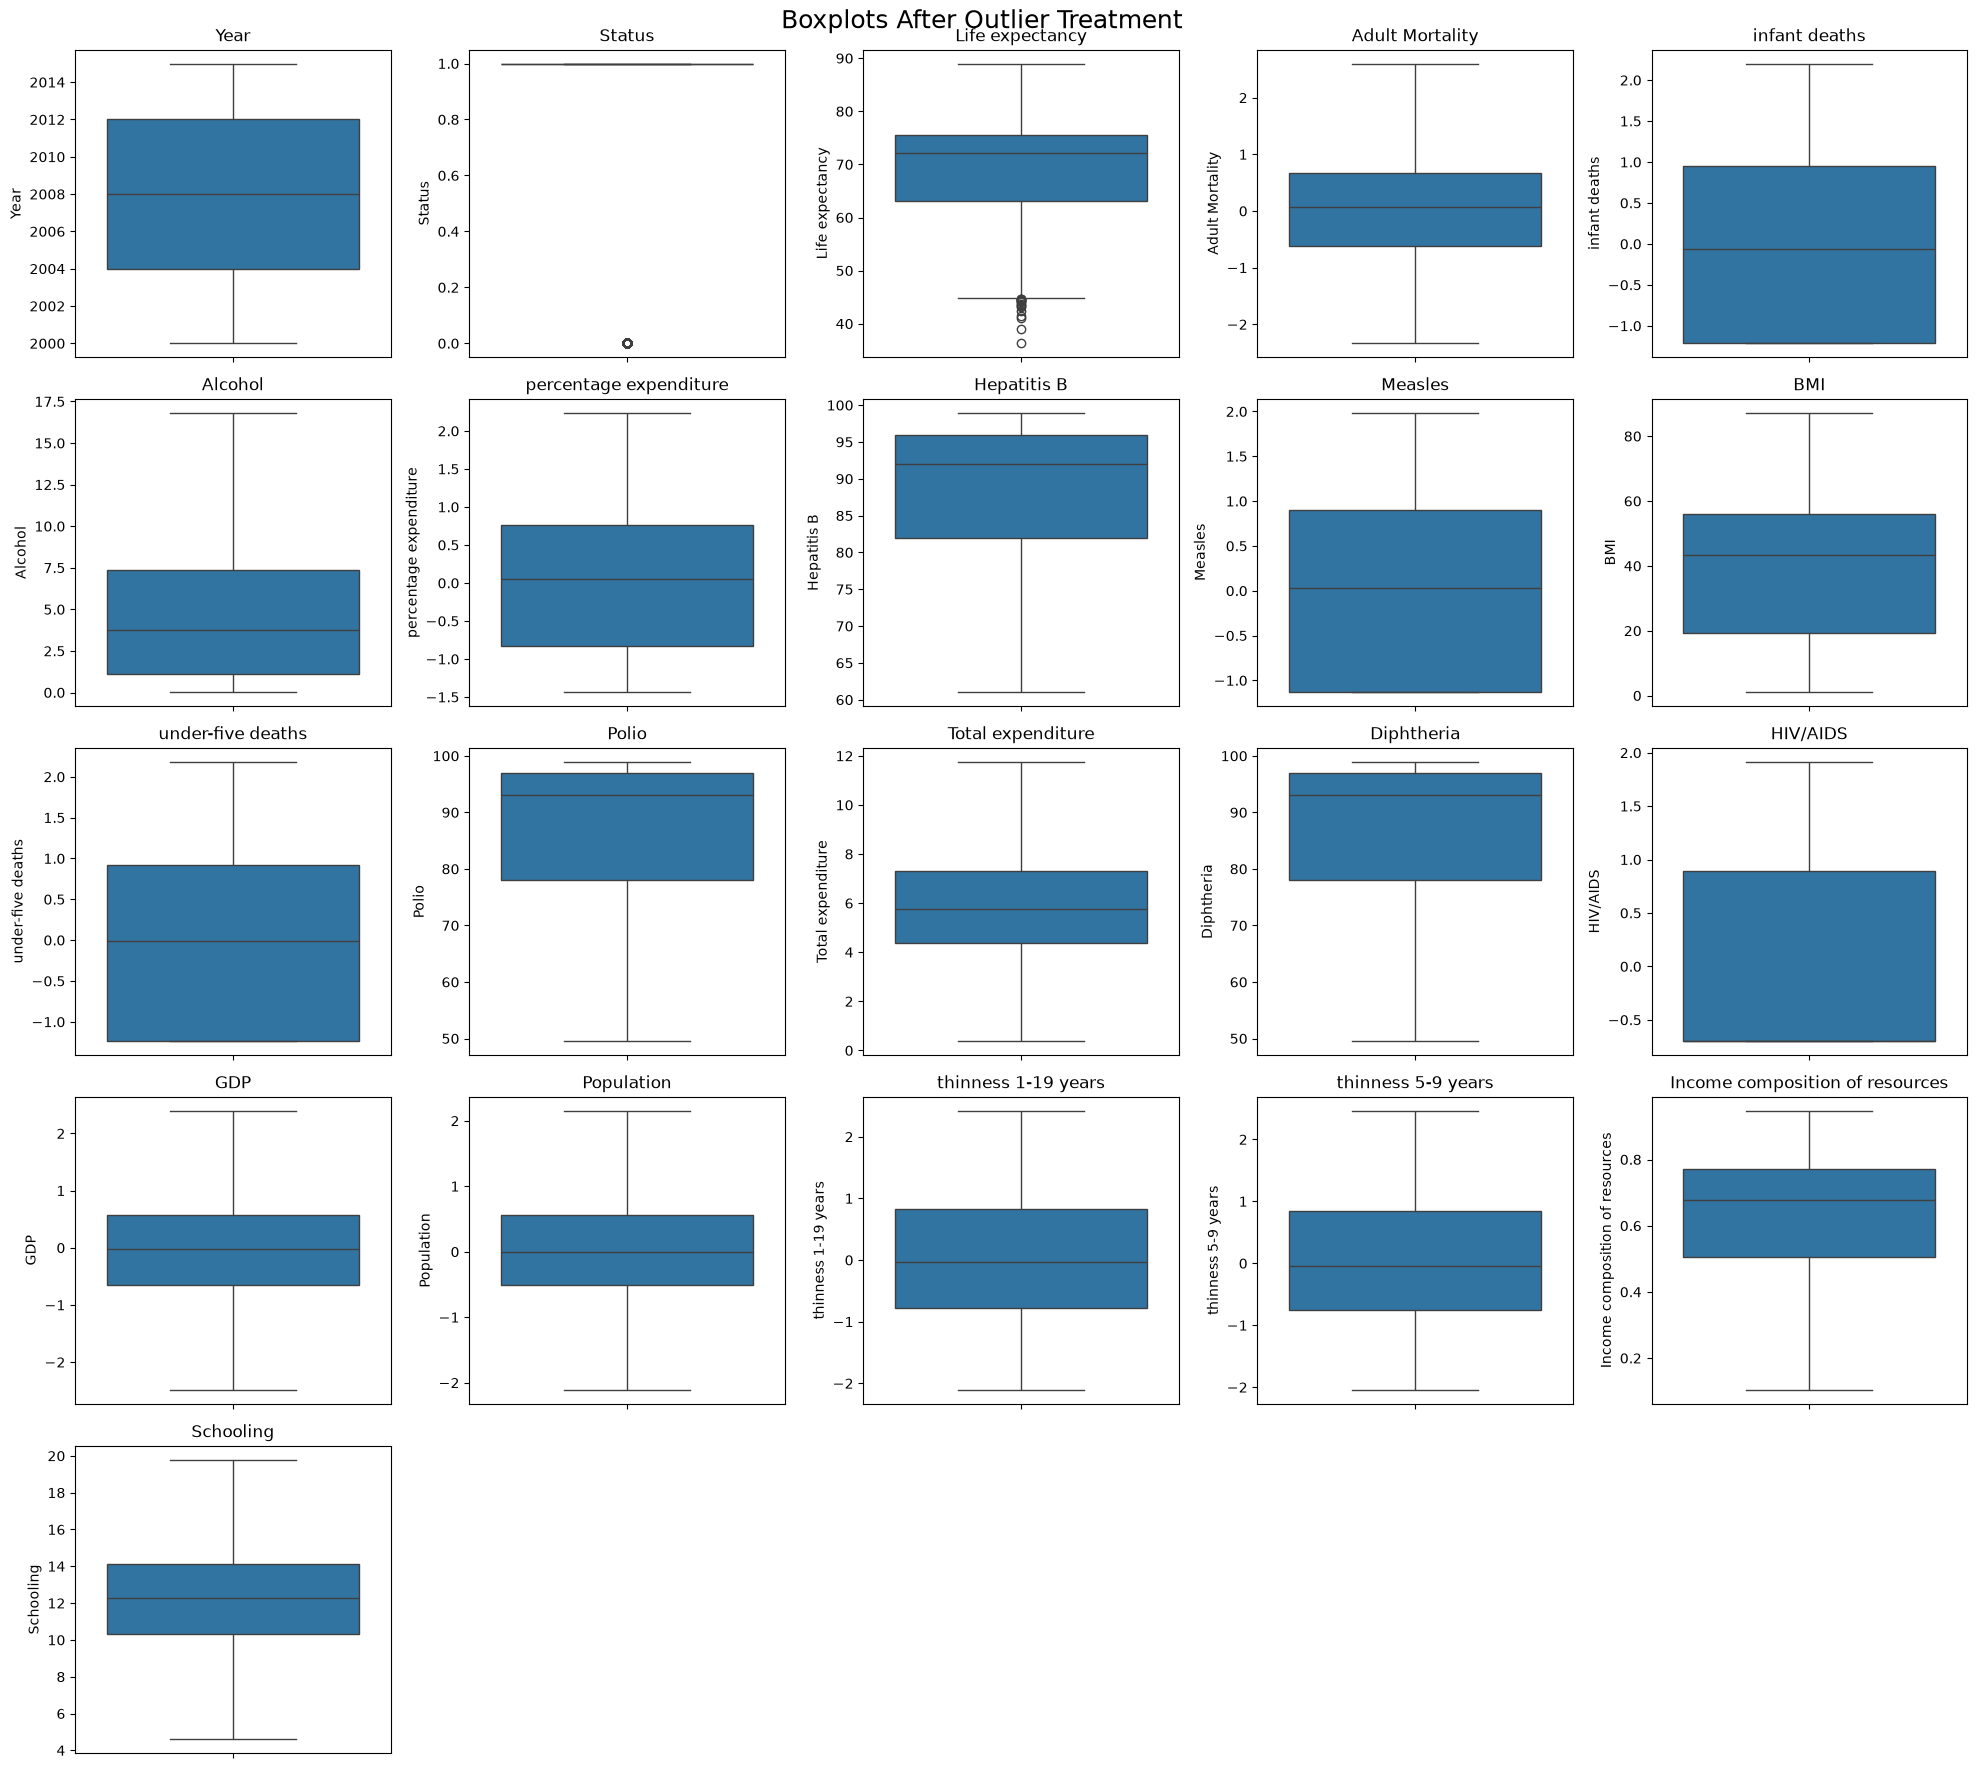

In [88]:
numeric_cols = df.select_dtypes(include=np.number).columns

fig, axes = plt.subplots(5, 5, figsize=(20, 18))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)

for i in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[i])

plt.suptitle('Boxplots After Outlier Treatment', fontsize=18)
plt.tight_layout()
plt.show()

In [92]:
#feature scaling
x=df.drop("Life expectancy", axis=1)
y=df["Life expectancy"]

In [96]:
X_train,X_test,y_train,y_test = train_test_split(
x,y,test_size=0.2,random_state=42
)

In [97]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [98]:
lr = LinearRegression()
lr.fit(X_train,y_train)
pred = lr.predict(X_test)

In [99]:
print("R2 :",r2_score(y_test,pred))
print("MAE :",mean_absolute_error(y_test,pred))
print("RMSE :",np.sqrt(mean_squared_error(y_test,pred)))

R2 : 0.8464954689158091
MAE : 2.768931043547398
RMSE : 3.6474420175571


In [100]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train,y_train)
pred_dt = dt.predict(X_test)

print(r2_score(y_test,pred_dt))

0.9236203174395926


In [101]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train,y_train)
pred_rf = rf.predict(X_test)
print(r2_score(y_test,pred_rf))

0.9686427042691474


In [102]:
svm = SVR()

svm.fit(X_train,y_train)
pred_svm = svm.predict(X_test)
print(r2_score(y_test,pred_svm))

0.9078733812073776


In [116]:
xgb = XGBRegressor(
    random_state=42
)

xgb.fit(X_train,y_train)
pred_xgb = xgb.predict(X_test)
print(r2_score(y_test,pred_xgb))

0.967435492639749


In [117]:
results = pd.DataFrame({

"Model":[
"Linear Regression",
"Decision Tree",
"Random Forest",
"SVM",
"XGBoost"
],

"R2 Score":[

r2_score(y_test,pred),
r2_score(y_test,pred_dt),
r2_score(y_test,pred_rf),
r2_score(y_test,pred_svm),
r2_score(y_test,pred_xgb)

]

})

results.sort_values(
"R2 Score",
ascending=False
)

,Model,R2 Score
2,Random Forest,0.968643
4,XGBoost,0.967435
1,Decision Tree,0.923620
3,SVM,0.907873
0,Linear Regression,0.846495


In [120]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

def evaluate_model(model, X_train, X_test, y_train, y_test):

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)

    mae = mean_absolute_error(y_test, test_pred)
    rmse = np.sqrt(mean_squared_error(y_test, test_pred))

    print(f"Model: {model.__class__.__name__}")
    print(f"Train R² : {train_r2:.4f}")
    print(f"Test R²  : {test_r2:.4f}")
    print(f"MAE      : {mae:.4f}")
    print(f"RMSE     : {rmse:.4f}")

    if train_r2 - test_r2 > 0.10:
        print("Overfitting: Yes")
    else:
        print("Overfitting: No")

    print("-"*40)

In [119]:
evaluate_model(LinearRegression(), X_train, X_test, y_train, y_test)

evaluate_model(DecisionTreeRegressor(random_state=42), X_train, X_test, y_train, y_test)

evaluate_model(RandomForestRegressor(random_state=42), X_train, X_test, y_train, y_test)

evaluate_model(SVR(), X_train, X_test, y_train, y_test)

evaluate_model(XGBRegressor(random_state=42), X_train, X_test, y_train, y_test)

Model: LinearRegression
Train R² : 0.8375
Test R²  : 0.8465
MAE      : 2.7689
RMSE     : 3.6474
Overfitting: No
----------------------------------------
Model: DecisionTreeRegressor
Train R² : 1.0000
Test R²  : 0.9236
MAE      : 1.5656
RMSE     : 2.5729
Overfitting: No
----------------------------------------
Model: RandomForestRegressor
Train R² : 0.9944
Test R²  : 0.9683
MAE      : 1.0756
RMSE     : 1.6576
Overfitting: No
----------------------------------------
Model: SVR
Train R² : 0.8936
Test R²  : 0.9079
MAE      : 1.9825
RMSE     : 2.8257
Overfitting: No
----------------------------------------
Model: XGBRegressor
Train R² : 0.9993
Test R²  : 0.9674
MAE      : 1.1337
RMSE     : 1.6800
Overfitting: No
----------------------------------------


In [121]:
#random forest is the most preferred model

In [125]:
import joblib
joblib.dump(rf, "random_forest_model.pkl")
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']